In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\Nat_Gas.csv")

In [3]:
df

,Dates,Prices
0,10/31/20,10.10
1,11/30/20,10.30
2,12/31/20,11.00
3,1/31/21,10.90
4,2/28/21,10.90
5,3/31/21,10.90
6,4/30/21,10.40
7,5/31/21,9.84
8,6/30/21,10.00
9,7/31/21,10.10


In [4]:
df['Dates'] = pd.to_datetime(df['Dates'])

C:\Users\Dell\AppData\Local\Temp\ipykernel_14816\2452315616.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


In [5]:
df

,Dates,Prices
0,2020-10-31,10.10
1,2020-11-30,10.30
2,2020-12-31,11.00
3,2021-01-31,10.90
4,2021-02-28,10.90
5,2021-03-31,10.90
6,2021-04-30,10.40
7,2021-05-31,9.84
8,2021-06-30,10.00
9,2021-07-31,10.10


In [6]:
import matplotlib.pyplot as plt

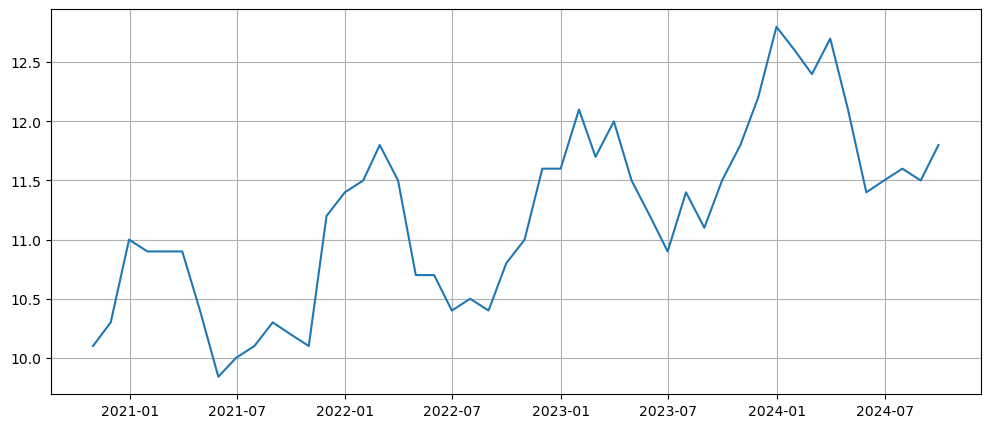

In [7]:
plt.figure(figsize=(12,5))
plt.plot(df['Dates'], df['Prices'])
plt.grid()
plt.show()

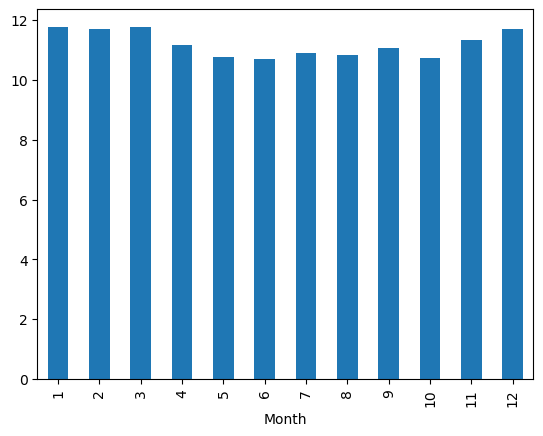

In [8]:
df['Month'] = df['Dates'].dt.month

monthly_avg = df.groupby('Month')['Prices'].mean()

monthly_avg.plot(kind='bar')
plt.show()

In [10]:
daily_df = (
    df.set_index('Dates')
      .resample('D')
      .interpolate(method='linear')
)

In [11]:
daily_df.loc['2023-07-15']

Prices    11.141935
Month      6.483871
Name: 2023-07-15 00:00:00, dtype: float64

In [17]:
future_dates = pd.date_range(
    start='2024-10-01',
    end='2026-09-30',
    freq='M'
)

future_prices = []

for d in future_dates:
    same_month = d.month
    avg_price = monthly_avg[same_month]
    future_prices.append(avg_price)

C:\Users\Dell\AppData\Local\Temp\ipykernel_14816\2265855987.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


In [13]:
future_df = pd.DataFrame({
    'Dates': future_dates,
    'Prices': future_prices
})

combined = pd.concat([
    df[['Dates','Prices']],
    future_df
])

In [14]:
combined_daily = (
    combined
    .set_index('Dates')
    .resample('D')
    .interpolate()
)

In [15]:
def estimate_price(date):

    date = pd.to_datetime(date)

    return float(
        combined_daily.loc[date]['Prices']
    )

In [19]:
print(
    estimate_price("2023-06-15")
)

print(
    estimate_price("2025-03-10")
)

11.05
11.724193548387097
